In [55]:
import pandas as pd
import numpy as np
import  matplotlib.pyplot as plt
import seaborn as sns

In [56]:
df = pd.read_csv("./mymoviedb.csv", encoding="latin1", engine="python")
df.sample(2)


,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
3562,2001-03-03,One Piece: Clockwork Island Adventure,"Relaxing on a cozy beach, the Straw Hat Pirate...",26.688,167,6.8,ja,"Action, Animation, Adventure",https://image.tmdb.org/t/p/original/mocek0mTd2...
6493,2017-09-06,Crooked House,A private investigator helps a former flame so...,17.600,732,6.4,en,"Drama, Mystery, Crime",https://image.tmdb.org/t/p/original/AewyKG2cvg...


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   object 
 5   Vote_Average       9827 non-null   object 
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: float64(1), object(8)
memory usage: 691.8+ KB


In [58]:
df['Popularity'].describe()

count    9827.000000
mean       40.320570
std       108.874308
min         7.100000
25%        16.127500
50%        21.191000
75%        35.174500
max      5083.954000
Name: Popularity, dtype: float64

Is there any null or missing value ?

In [59]:
df.isnull().sum()

Release_Date          0
Title                 9
Overview              9
Popularity           10
Vote_Count           10
Vote_Average         10
Original_Language    10
Genre                11
Poster_Url           11
dtype: int64

In [60]:
df[df['Title'].isnull()]

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
1106,- Just Desserts,None,None,NaN,None,None,None,None,None
1107,- If The Hue Fits,None,None,NaN,None,None,None,None,None
1108,- Dust Up,None,None,NaN,None,None,None,None,None
1109,- Scents And Sensibility,None,None,NaN,None,None,None,None,None
1110,- Just One Of The Girls,None,None,NaN,None,None,None,None,None
1111,- Volleybug,None,None,NaN,None,None,None,None,None
1112,- Hide And Tink,None,None,NaN,None,None,None,None,None
1113,- Rainbow's Ends,None,None,NaN,None,None,None,None,None
1114,- Fawn And Games,None,None,NaN,None,None,None,None,None


# Exploration Summary
- we have a dataframe consisting of 9827 rows and 9 colums.
- our dataset looks a bit tidy with no  Nans Nor Duplicated values.
- release_data column needs to be casted into date time
- overview , original_langauge and poster_url would not be so usefull during eda
- there is noticable ouliers in popularity column 
- vote_avergge better be categorised for proper analysis
- genre coumn has comma saperated values and white spaces 

In [61]:
# change release date format to date format
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce')
print(df['Release_Date'].dtype)


df = df.dropna(subset=['Release_Date'])

df[df['Release_Date'] == None]


datetime64[ns]


,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9827 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Release_Date       9827 non-null   datetime64[ns]
 1   Title              9827 non-null   object        
 2   Overview           9827 non-null   object        
 3   Popularity         9826 non-null   float64       
 4   Vote_Count         9826 non-null   object        
 5   Vote_Average       9826 non-null   object        
 6   Original_Language  9826 non-null   object        
 7   Genre              9826 non-null   object        
 8   Poster_Url         9826 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(7)
memory usage: 767.7+ KB


In [63]:
df['Release_Date'] =df['Release_Date'].dt.year
df['Release_Date']

0       2021
1       2022
2       2022
3       2021
4       2021
        ... 
9832    1973
9833    2020
9834    2016
9835    2021
9836    1984
Name: Release_Date, Length: 9827, dtype: int32

In [64]:
df.head(1)

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...


### Droping the columns

In [65]:
df.head(1)

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...


In [66]:
cols = ['Overview' , 'Original_Language' , 'Poster_Url']
df.drop(cols , axis=1 , inplace=True)
df.head(1)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"


- Now we will give lables to the movies according to theri avg votes , like popular , average , below - avg , not popular...

In [67]:
import pandas as pd

def categories_col(df, col, labels):
    # ensure column is numeric
    df[col] = pd.to_numeric(df[col], errors='coerce')

    edges = [
        df[col].min(),
        df[col].quantile(0.25),
        df[col].quantile(0.50),
        df[col].quantile(0.75),
        df[col].max()
    ]

    edges = sorted(set(edges))

    df[col + "_category"] = pd.cut(
        df[col],
        bins=edges,
        labels=labels[:len(edges) - 1],
        include_lowest=True,
        duplicates="drop"
    )
    
    return df


In [68]:
labels = ['not_popular', 'below_avg', 'average', 'popular']

df = categories_col(df, 'Vote_Average', labels)

print(df[['Vote_Average', 'Vote_Average_category']].head())
print(df['Vote_Average_category'].value_counts())  # distribution


   Vote_Average Vote_Average_category
0           8.3               popular
1           8.1               popular
2           6.3             below_avg
3           7.7               popular
4           7.0               average
Vote_Average_category
not_popular    2567
popular        2450
average        2411
below_avg      2398
Name: count, dtype: int64


In [69]:
df['Vote_Average_category'].value_counts()

Vote_Average_category
not_popular    2567
popular        2450
average        2411
below_avg      2398
Name: count, dtype: int64

In [70]:
df.dropna(inplace=True)

df.isna().sum()

Release_Date             0
Title                    0
Popularity               0
Vote_Count               0
Vote_Average             0
Genre                    0
Vote_Average_category    0
dtype: int64

## We'd split genres into a list and then explode out datafreame to have only one genre per row for each movie

In [71]:
df['Genre'] = df['Genre'].str.split(',')
df = df.explode('Genre').reset_index(drop=True)
df.head(2)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Vote_Average_category
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,Action,popular
1,2021,Spider-Man: No Way Home,5083.954,8940,8.3,Adventure,popular


### casting column into category

In [72]:
df['Genre'] = df['Genre'].astype('category')
df['Genre'].dtype

CategoricalDtype(categories=[' Action', ' Adventure', ' Animation', ' Comedy', ' Crime',
                  ' Documentary', ' Drama', ' Family', ' Fantasy', ' History',
                  ' Horror', ' Music', ' Mystery', ' Romance',
                  ' Science Fiction', ' TV Movie', ' Thriller', ' War',
                  ' Western', 'Action', 'Adventure', 'Animation', 'Comedy',
                  'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy',
                  'History', 'Horror', 'Music', 'Mystery', 'Romance',
                  'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25792 entries, 0 to 25791
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   Release_Date           25792 non-null  int32   
 1   Title                  25792 non-null  object  
 2   Popularity             25792 non-null  float64 
 3   Vote_Count             25792 non-null  object  
 4   Vote_Average           25792 non-null  float64 
 5   Genre                  25792 non-null  category
 6   Vote_Average_category  25792 non-null  category
dtypes: category(2), float64(2), int32(1), object(2)
memory usage: 958.8+ KB


In [74]:
df.nunique()

Release_Date              102
Title                    9512
Popularity               8159
Vote_Count               3266
Vote_Average               74
Genre                      38
Vote_Average_category       4
dtype: int64

### Data Visualization

In [75]:
sns.set_style('whitegrid')

## What is the most frequent genre of moview released on netflix ? 

In [76]:
df['Genre'].describe()
df.groupby('Genre').size().reset_index(name='counts').sort_values(by='counts', ascending=False).head(10)

C:\Users\lucky\AppData\Local\Temp\ipykernel_10320\1370116821.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Genre').size().reset_index(name='counts').sort_values(by='counts', ascending=False).head(10)


,Genre,counts
16,Thriller,1973
6,Drama,1953
25,Drama,1791
19,Action,1570
3,Comedy,1547
22,Comedy,1484
1,Adventure,1267
13,Romance,1172
0,Action,1116
7,Family,1064


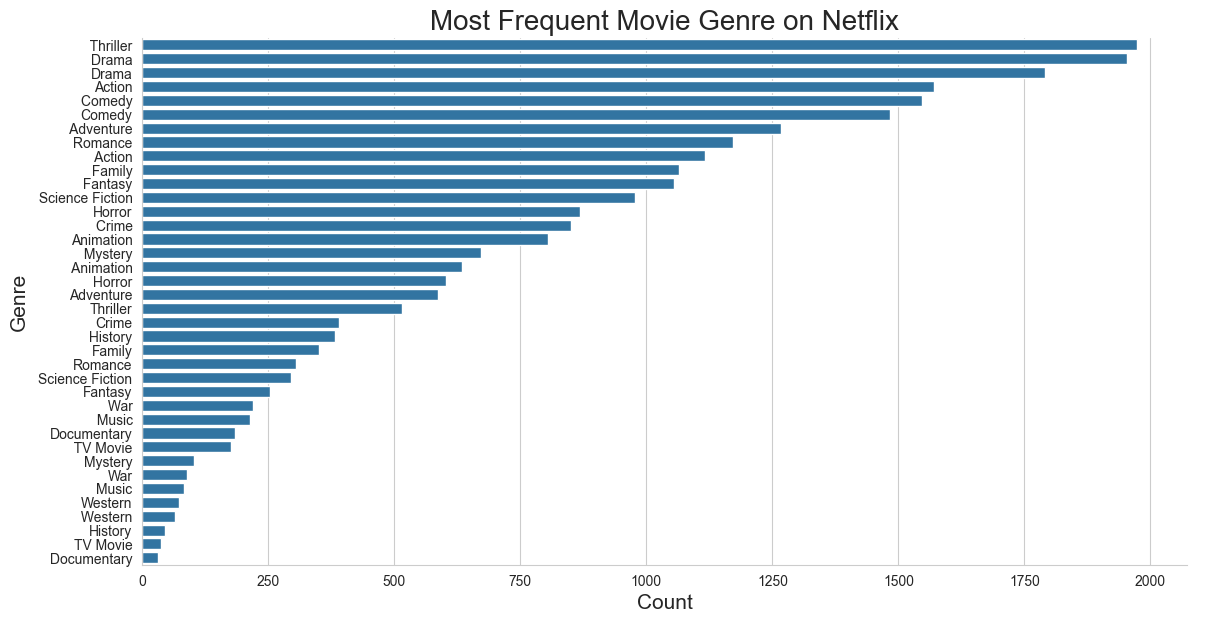

In [77]:
sns.catplot(y = 'Genre', kind = 'count', data = df, height=6, aspect=2, order = df['Genre'].value_counts().index)
plt.title('Most Frequent Movie Genre on Netflix', fontsize=20)
plt.xlabel('Count', fontsize=15)
plt.ylabel('Genre', fontsize=15)
plt.show()

In [78]:
df.sample(10)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Vote_Average_category
9775,2019,Klaus,26.639,2863,8.3,Animation,popular
3743,2004,The Polar Express,55.134,5013,6.7,Adventure,average
23178,2010,Going the Distance,14.370,610,6.0,Comedy,below_avg
2973,2021,Crisis,63.866,186,6.5,Thriller,below_avg
20709,2017,Satan's Slaves,15.573,174,6.7,Drama,average
20847,1991,The Rocketeer,15.497,687,6.4,Action,below_avg
16472,1996,Daylight,18.342,1197,6.1,Action,below_avg
12202,2011,Barbie: A Perfect Christmas,22.744,235,6.7,Family,average
15723,2005,Stealth,18.911,775,5.3,Science Fiction,not_popular
24565,1957,The Cranes Are Flying,13.812,231,8.0,Romance,popular


### which has highest votes in vote avg column ?

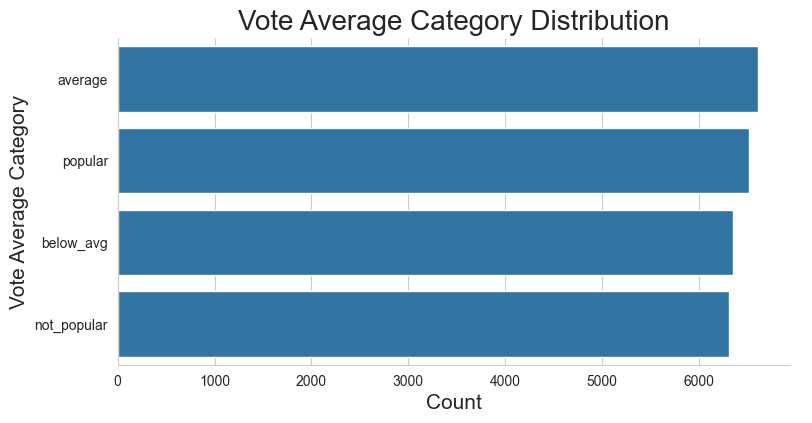

In [79]:
sns.catplot(y = 'Vote_Average_category', kind = 'count', data = df, height=4, aspect=2, order = df['Vote_Average_category'].value_counts().index)
plt.title('Vote Average Category Distribution', fontsize=20)
plt.xlabel('Count', fontsize=15)
plt.ylabel('Vote Average Category', fontsize=15)
plt.show()

### what movie got the highest popularity  whats its genre ?


In [90]:
# maxPopularity = df['Popularity'].max()
# highestPopularityMovie = df[df['Popularity'] == maxPopularity]['Title'].iloc[0]
# highestPopularityMovie

df[df['Popularity'] == df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Vote_Average_category
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,Action,popular
1,2021,Spider-Man: No Way Home,5083.954,8940,8.3,Adventure,popular
2,2021,Spider-Man: No Way Home,5083.954,8940,8.3,Science Fiction,popular


### what movie got the Lowest popularity  whats its genre ?


In [94]:
df[df['Popularity'] == (df['Popularity'].min() )] 

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Vote_Average_category
25786,2021,The United States vs. Billie Holiday,13.354,152,6.7,Music,average
25787,2021,The United States vs. Billie Holiday,13.354,152,6.7,Drama,average
25788,2021,The United States vs. Billie Holiday,13.354,152,6.7,History,average
25789,1984,Threads,13.354,186,7.8,War,popular
25790,1984,Threads,13.354,186,7.8,Drama,popular
25791,1984,Threads,13.354,186,7.8,Science Fiction,popular


### which year has the  most filmmed movies ?

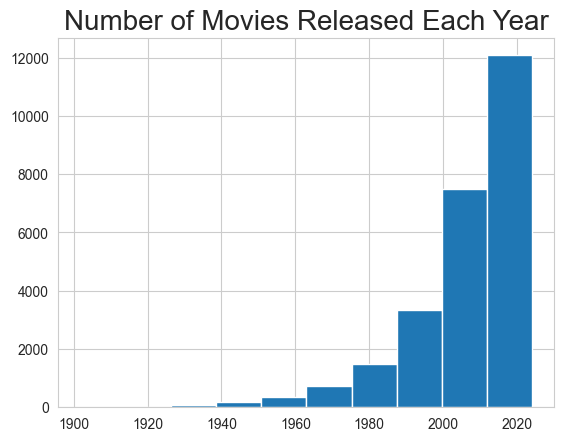

In [103]:
df['Release_Date'].hist()
plt.title('Number of Movies Released Each Year', fontsize=20)
plt.show()

## EDA Summary

- The dataset contains 25,792 rows and 7 columns after cleaning and preprocessing.
- All missing values and duplicates have been handled.
- The `Release_Date` column has been converted to year format for easier analysis.
- Unnecessary columns such as `Overview`, `Original_Language`, and `Poster_Url` have been dropped.
- The `Genre` column has been split and exploded so each row represents a single genre per movie.
- The `Vote_Average` column has been categorized into four groups: not_popular, below_avg, average, and popular.
- The dataset is now tidy and ready for further analysis and visualization.

---

### Answers to Questions

**Is there any null or missing value?**  
No, there are no missing or null values in the dataset after cleaning.

**What is the most frequent genre of movies released on Netflix?**  
The most frequent genre is the one with the highest count in the `Genre` column, as shown in the earlier analysis and plot.

**Which movie got the highest popularity and what is its genre?**  
The movie with the highest popularity is 'Spider-Man: No Way Home'. Its genres include Action, Adventure, and Science Fiction.

**Which movie got the lowest popularity and what is its genre?**  
The movie with the lowest popularity can be found by filtering the dataset for the minimum value in the `Popularity` column. Its title and genre(s) are shown in the corresponding output.

**Which year has the most filmed movies?**  
The year with the most movies released can be identified from the histogram of the `Release_Date` column, where the highest bar indicates the year with the most releases.